# Porównanie metod ścieniania oraz detekcja minucji

Notatnik porównuje trzy metody ścieniania:
1. Szkieletyzacja morfologiczna
2. Algorytm KMM
3. Algorytm K3M

Na powstałych szkieletach wyznaczane są minucje – zakończenia linii i bifurkacje – metodą Crossing Number.

## 0. Środowisko

In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import sys
from pathlib import Path

PROJEKT3_ROOT = Path().resolve().parent
PROJEKT1_ROOT = PROJEKT3_ROOT.parent / "Projekt1"
for _p in (str(PROJEKT1_ROOT), str(PROJEKT3_ROOT)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

print("Projekt1:", PROJEKT1_ROOT, PROJEKT1_ROOT.is_dir())
print("Projekt3:", PROJEKT3_ROOT, PROJEKT3_ROOT.is_dir())

Projekt1: D:\Git stuff\Biometria_2026L\Projekt1 True
Projekt3: D:\Git stuff\Biometria_2026L\Projekt3 True


In [45]:
import numpy as np
import matplotlib.pyplot as plt

from backend import (
    load_image_to_numpy,
    plot_numpy_image,
    binarize_image,
    skeletonize,
    invert_image
)
from backend.pixel_functions import convert_to_grayscale

from backend_fingerprints import kmm, k3m, detect_minutiae, connect_ridges

## 1. Wczytanie i binaryzacja obrazu

Jeśli obraz jest RGB, najpierw konwertujemy do skali szarości, a potem binaryzujemy z progiem `threshold`. Odciski palców mają ciemne linie, więc foreground = "dark".

shape: (274, 184, 3) dtype: uint8


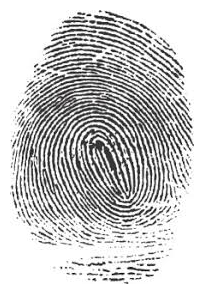

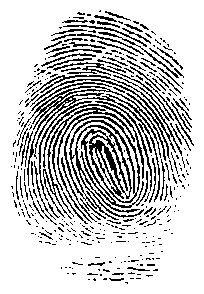

In [46]:
FINGERPRINT_PATH = PROJEKT3_ROOT / "data" / "fingerprint.jpg" # ŚCIEŻKA DO ZDJĘCIA
BINARIZATION_THRESHOLD = 128
FOREGROUND = "dark"  # "dark" lub "light"

img = load_image_to_numpy(str(FINGERPRINT_PATH))
print("shape:", img.shape, "dtype:", img.dtype)

# jeśli zdjęcie jest RGB – sprowadźmy do odcieni szarości, żeby binaryzacja była jednoznaczna
if img.ndim == 3:
    img_gray = convert_to_grayscale(img)
else:
    img_gray = img

img_bin = binarize_image(img_gray, threshold=BINARIZATION_THRESHOLD)

plot_numpy_image(img)
plot_numpy_image(img_bin)

## 2. Domknięcie morfologiczne (łączenie poprzerywanych linii)

Szumy w obrazie potrafią powodować "przerwy" w liniach papilarnych. Przed ścienianiem opłacalne bywa wykonanie domknięcia morfologicznego, które nieco je sklei.

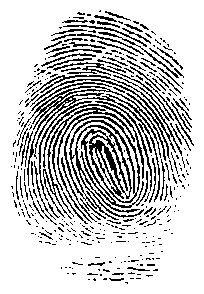

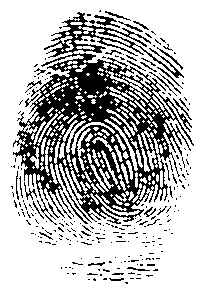

In [47]:
img_connected = connect_ridges(img_bin, foreground=FOREGROUND)

plot_numpy_image(img_bin)
plot_numpy_image(img_connected)

## 3. Porównanie trzech metod ścieniania

Wszystkie trzy metody przyjmują obraz binarny (0/255) i zwracają obraz binarny (0/255) ze ścienionym szkieletem.

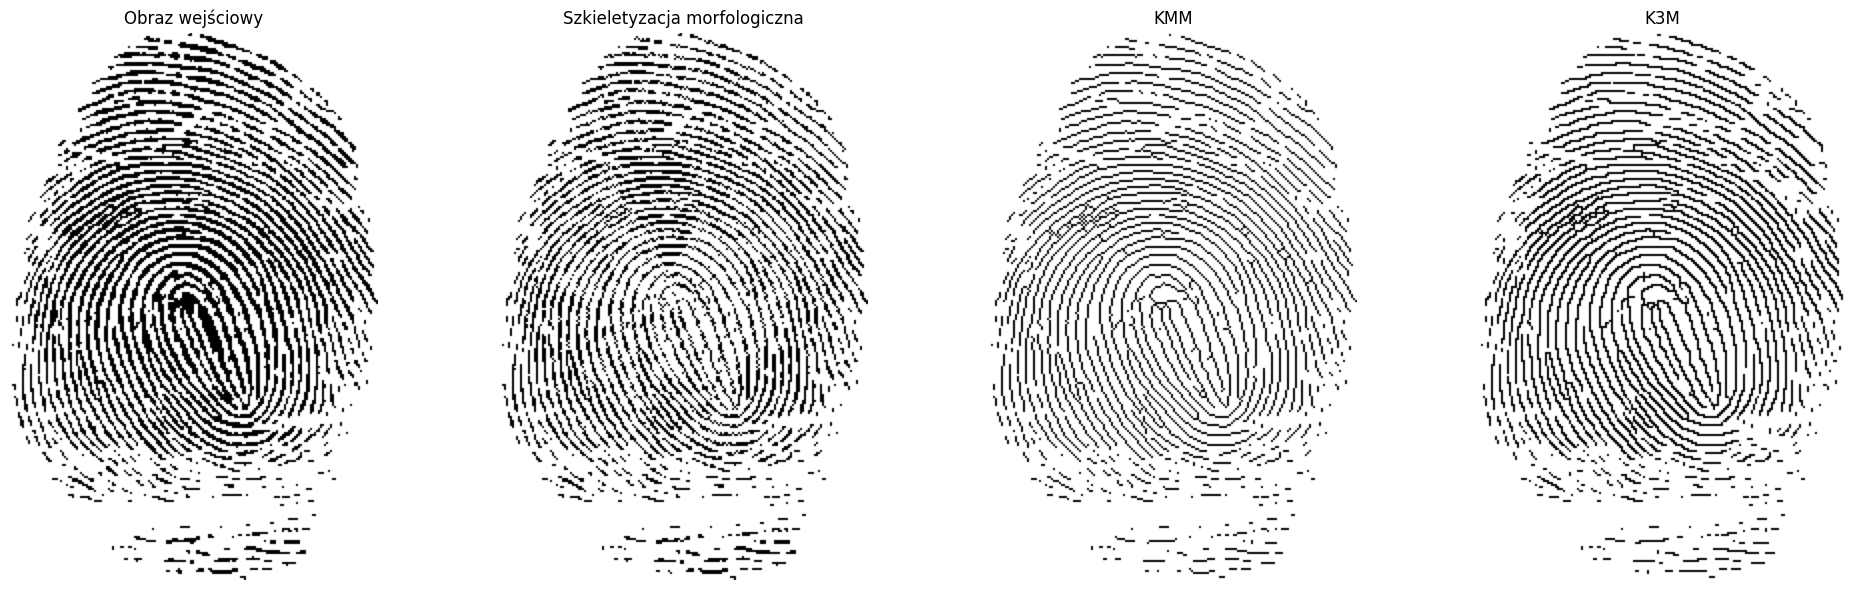

In [49]:
source = img_bin # lub img_connected w razie potrzeby

# szkieletyzacja morfologiczna
# nasza implementacja szkieletyzacji operuje na czarnym tle i białych konturach, więc trzeba odpowiednio wziąć negatywy inputu i outputu 
skel_morph = invert_image(skeletonize(invert_image(source), binarization_threshold=BINARIZATION_THRESHOLD))
# KMM
skel_kmm = kmm(source, foreground=FOREGROUND)
# K3M
skel_k3m = k3m(source, foreground=FOREGROUND)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, im, title in zip(
    axes,
    [source, skel_morph, skel_kmm, skel_k3m],
    ["Obraz wejściowy", "Szkieletyzacja morfologiczna", "KMM", "K3M"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3a. Ile pikseli pozostało w szkielecie?

Szkielet powinien mieć szerokość jednego piksela, więc liczba pikseli po ścienianiu powinna być drastycznie niższa niż w obrazie wejściowym.

In [50]:
def _fg_count(im, foreground=FOREGROUND):
    # foreground = ciemny oznacza, że ridge'e mają wartość 0
    return int(np.sum(im == 0)) if foreground == "dark" else int(np.sum(im == 255))

print(f"Obraz wejściowy (po domknięciu): {_fg_count(source)}")
print(f"Morfologiczny szkielet:          {_fg_count(skel_morph)}")
print(f"Szkielet KMM:                    {_fg_count(skel_kmm)}")
print(f"Szkielet K3M:                    {_fg_count(skel_k3m)}")

Obraz wejściowy (po domknięciu): 12890
Morfologiczny szkielet:          9513
Szkielet KMM:                    6498
Szkielet K3M:                    8543


## 4. Detekcja minucji

Dla każdego szkieletu liczymy mapę metodą Crossing Number (CN) i wyznaczamy:
- **zakończenia linii** (CN = 1),
- **bifurkacje** (CN = 3).

Minucje nanosimy na wizualizację szkieletu.

In [70]:
def visualise_minutiae(ax, skeleton, title, foreground=FOREGROUND, border_margin=2):
    # detekcja: CN=1 -> ending, CN=3 -> bifurkacja
    result = detect_minutiae(skeleton, foreground=foreground, border_margin=border_margin)
    endings = result["endings"]
    bifs = result["bifurcations"]

    ax.imshow(skeleton, cmap="gray", vmin=0, vmax=255)

    # rysujemy punkty: zakończenia na czerwono, bifurkacje na zielono
    if endings.size > 0:
        ax.scatter(endings[:, 1], endings[:, 0], c="red", s=18, label=f"zakończenia ({len(endings)})")
    if bifs.size > 0:
        ax.scatter(bifs[:, 1], bifs[:, 0], c="lime", s=18, label=f"bifurkacje ({len(bifs)})")

    ax.set_title(f"{title} | zakończenia linii: {len(endings)}, bifurkacje: {len(bifs)}")
    ax.axis("off")
    ax.legend(loc="upper right")
    return result

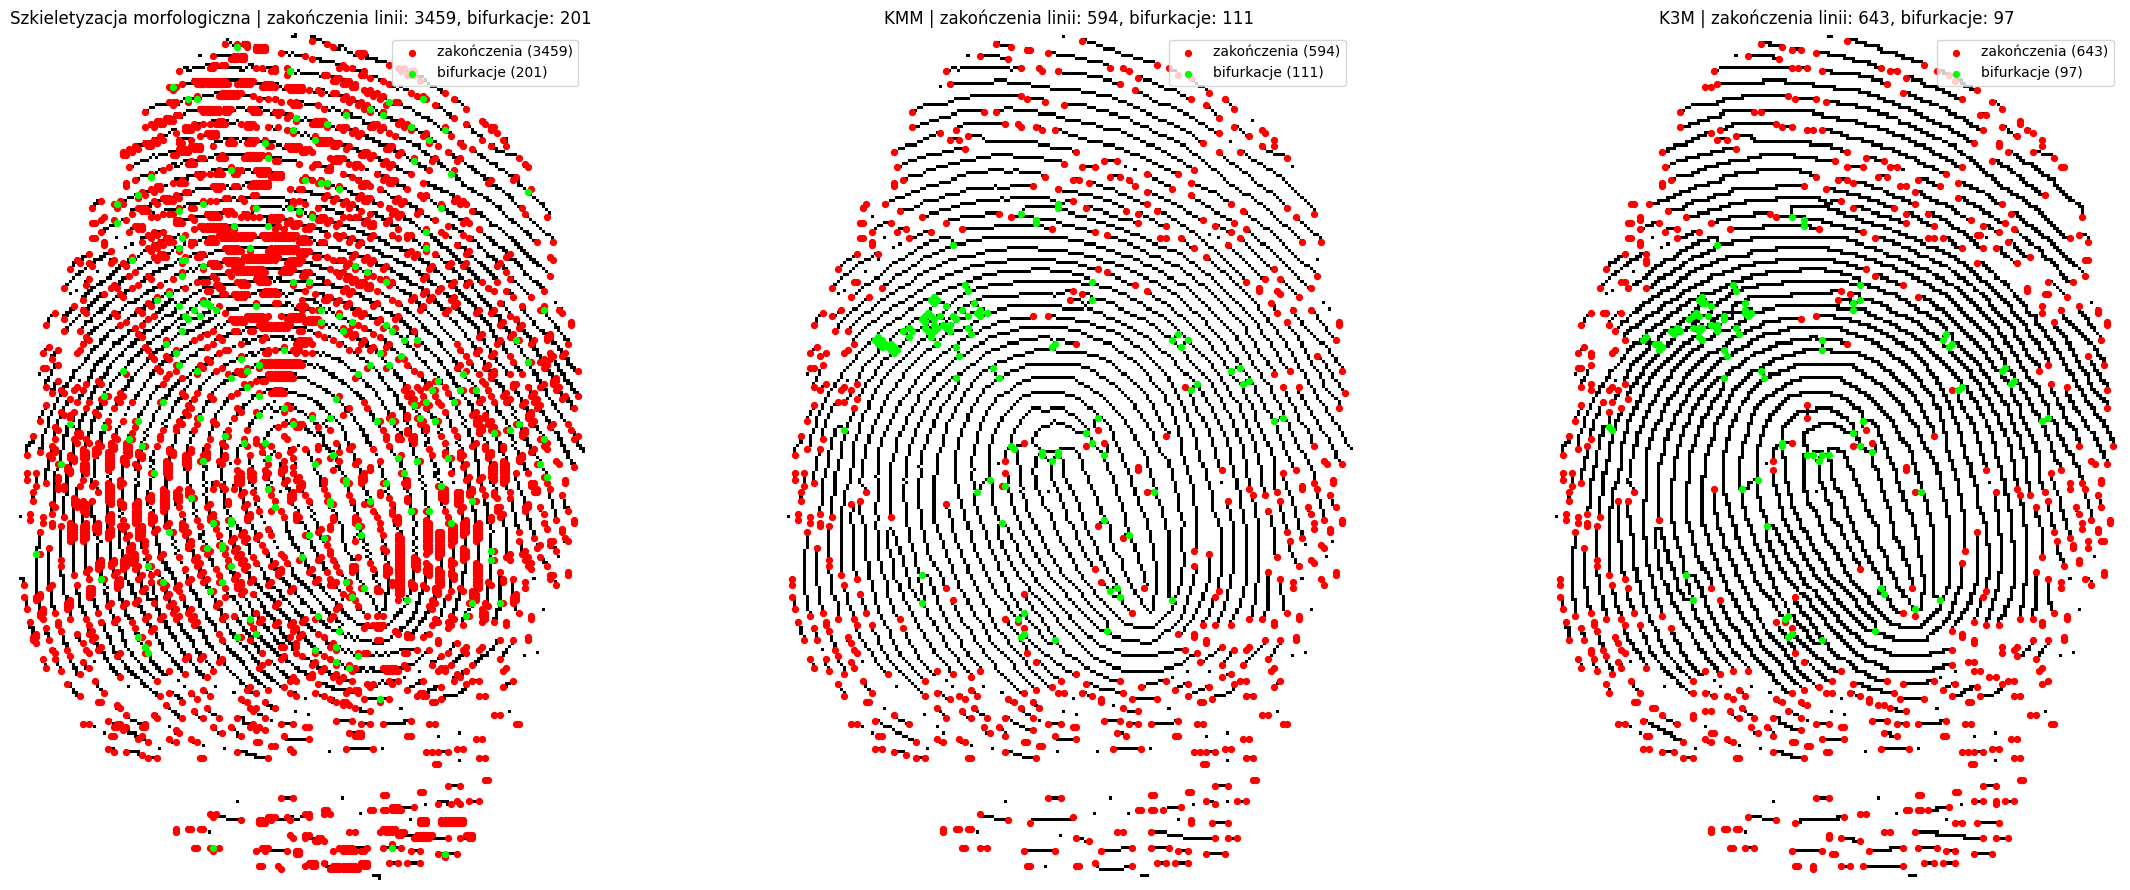

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(24, 9))

res_morph = visualise_minutiae(axes[0], skel_morph, "Szkieletyzacja morfologiczna")
res_kmm   = visualise_minutiae(axes[1], skel_kmm,   "KMM")
res_k3m   = visualise_minutiae(axes[2], skel_k3m,   "K3M")

plt.tight_layout()
plt.show()

## 5. Podsumowanie liczby minucji

Liczba wykrytych minucji zależy wprost od jakości szkieletu. Algorytmy, które zostawią więcej "wąsów" (drobnych odgałęzień), dadzą dużo fałszywych zakończeń linii.

In [53]:
print(f"{'metoda':<28} {'endings':>10} {'bifurcations':>14}")
for name, res in [
    ("szkielet. morfologiczna", res_morph),
    ("KMM", res_kmm),
    ("K3M", res_k3m),
]:
    print(f"{name:<28} {len(res['endings']):>10} {len(res['bifurcations']):>14}")

metoda                          endings   bifurcations
szkielet. morfologiczna            3459            201
KMM                                 594            111
K3M                                 643             97
